#Chargement de la base de données

In [ ]:
!wget http://cs231n.stanford.edu/tiny-imagenet-200.zip
!unzip tiny-imagenet-200.zip

Streaming output truncated to the last 5000 lines.
  inflating: tiny-imagenet-200/val/images/val_3979.JPEG  
  inflating: tiny-imagenet-200/val/images/val_3963.JPEG  
  inflating: tiny-imagenet-200/val/images/val_7199.JPEG  
  inflating: tiny-imagenet-200/val/images/val_2752.JPEG  
  inflating: tiny-imagenet-200/val/images/val_9687.JPEG  
  inflating: tiny-imagenet-200/val/images/val_9407.JPEG  
  inflating: tiny-imagenet-200/val/images/val_3603.JPEG  
  inflating: tiny-imagenet-200/val/images/val_3412.JPEG  
  inflating: tiny-imagenet-200/val/images/val_6982.JPEG  
  inflating: tiny-imagenet-200/val/images/val_8496.JPEG  
  inflating: tiny-imagenet-200/val/images/val_7332.JPEG  
  inflating: tiny-imagenet-200/val/images/val_9241.JPEG  
  inflating: tiny-imagenet-200/val/images/val_4196.JPEG  
  inflating: tiny-imagenet-200/val/images/val_5980.JPEG  
  inflating: tiny-imagenet-200/val/images/val_6697.JPEG  
  inflating: tiny-imagenet-200/val/images/val_9969.JPEG  
  inflating: tiny-ima

#Indexation visuelle : SIFT, LBP, HOG, CNN embeddings

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from skimage.feature import local_binary_pattern
from tqdm import tqdm
from tensorflow.keras.applications import ResNet50, resnet50
from tensorflow.keras.preprocessing import image

# --- Paramètres ---
DATASET_DIR = "tiny-imagenet-200/train"
NUM_CLASSES = 10  # on prend 10 classes pour simplifier
IMAGES_PER_CLASS = 5
IMAGE_SIZE = (128, 128)

# --- Charger un sous-ensemble du dataset ---
def load_dataset(path, num_classes=10, per_class=5):
    data = []
    labels = []
    class_folders = sorted(os.listdir(path))[:num_classes]
    for label, folder in enumerate(class_folders):
        img_dir = os.path.join(path, folder, 'images')
        imgs = sorted(os.listdir(img_dir))[:per_class]
        for img_name in imgs:
            img_path = os.path.join(img_dir, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, IMAGE_SIZE)
                data.append(img)
                labels.append(label)
    return np.array(data), np.array(labels), class_folders

images, labels, class_names = load_dataset(DATASET_DIR, NUM_CLASSES, IMAGES_PER_CLASS)
print(f"{len(images)} images chargées.")

# --- Méthodes d’indexation ---

# -----------------------------
#        SIFT (Couleur)
# -----------------------------
def extract_sift_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    sift = cv2.SIFT_create()
    kp, des = sift.detectAndCompute(gray, None)
    return np.mean(des, axis=0) if des is not None else np.zeros(128)

def extract_orb_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    orb = cv2.ORB_create()
    kp, des = orb.detectAndCompute(gray, None)
    return np.mean(des, axis=0) if des is not None else np.zeros(32)

# -----------------------------
#       LBP (Texture)
# -----------------------------
def extract_lbp_features(img, P=8, R=1):
    """
    LBP (Local Binary Pattern) : encode la texture locale.
    P = nombre de points voisins
    R = rayon
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, P, R, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, P + 3), range=(0, P + 2))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)  # normalisation
    return hist

# -----------------------------
#         HOG (Forme)
# -----------------------------
def extract_hog_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hog = cv2.HOGDescriptor()
    return hog.compute(gray).flatten()

# -----------------------------
#  CNN Embeddings (ResNet18)
# -----------------------------
resnet = ResNet50(weights='imagenet', include_top=False, pooling='avg')

def extract_cnn_features(img):
    img_resized = cv2.resize(img, (224, 224))
    x = image.img_to_array(img_resized)
    x = np.expand_dims(x, axis=0)
    x = resnet50.preprocess_input(x)
    feat = resnet.predict(x, verbose=0)
    return feat.flatten()

# --- Extraction ---
methods = {
    "SIFT": extract_sift_features,
    "LBP": extract_lbp_features,
    "HOG": extract_hog_features,
    "CNN": extract_cnn_features
}

features = {}
for name, func in methods.items():
    feats = [func(img) for img in tqdm(images, desc=f"Extraction {name}")]
    features[name] = np.array(feats)


# --- Recherche d’images similaires ---
"""----------------------------------------
-----------------------------------------
-----------------------------------------"""

50 images chargées.


Extraction CNN: 100%|██████████| 50/50 [00:12<00:00,  3.93it/s]


'----------------------------------------\n-----------------------------------------\n-----------------------------------------'

**Dans notre code **

## **Question 1 : Taille totale du sous-ensemble d'images chargé**

In [ ]:
import os

# Chemin vers le dossier train du dataset Tiny ImageNet décompressé
train_dir = "tiny-imagenet-200/train"

# Liste des classes (chaque classe est un sous-dossier)
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
num_classes = len(classes)
print(num_classes)

200


# **Question 2 : Combien de classes et combien d'images par classe**

In [ ]:
# Question 2
import os
train_dir = "tiny-imagenet-200/train"
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
images_per_class = len(os.listdir(os.path.join(train_dir, classes[0], 'images')))

print(f"Nombre de classes: {len(classes)}")
print(f"Images par classe: {images_per_class}")

Nombre de classes: 200
Images par classe: 500


# **Question 3 : Taille du vecteur produit par les différents descripteurs**

In [ ]:
# Question 3
for method, feat in features.items():
    print(f"{method}: {feat.shape[1]} dimensions")

SIFT: 128 dimensions
LBP: 10 dimensions
HOG: 34020 dimensions
CNN: 2048 dimensions


# **Question 4 : Fonction de recherche d'images similaires**

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def search_similar_images(query_idx, method_name, k=5):
    feat_matrix = features[method_name]
    query_vec = feat_matrix[query_idx].reshape(1, -1)
    sims = cosine_similarity(query_vec, feat_matrix)[0]
    top_k_idx = np.argsort(sims)[::-1][1:k+1]
    return top_k_idx, sims[top_k_idx]

# Test
query_idx = 0
method = "CNN"
k = 5
indices, sims = search_similar_images(query_idx, method, k)

print(f"Image requête: {query_idx} | Classe: {class_names[labels[query_idx]]}")
print(f"Méthode: {method}\n")
for i, (idx, sim) in enumerate(zip(indices, sims), 1):
    print(f"{i}. Img {idx} | Classe: {class_names[labels[idx]]} | Similarité: {sim:.4f}")

Image requête: 0 | Classe: n01443537
Méthode: CNN

1. Img 3 | Classe: n01443537 | Similarité: 0.6295
2. Img 4 | Classe: n01443537 | Similarité: 0.6276
3. Img 17 | Classe: n01644900 | Similarité: 0.5825
4. Img 1 | Classe: n01443537 | Similarité: 0.5801
5. Img 2 | Classe: n01443537 | Similarité: 0.5563


# **Question 5 : Afficher l'image requête et les k images les plus similaires avec similarité**


Méthode: SIFT


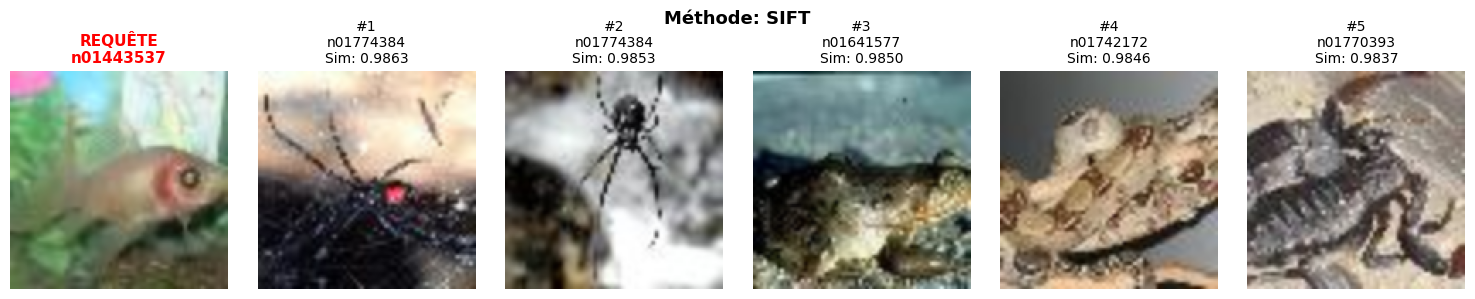


Méthode: LBP


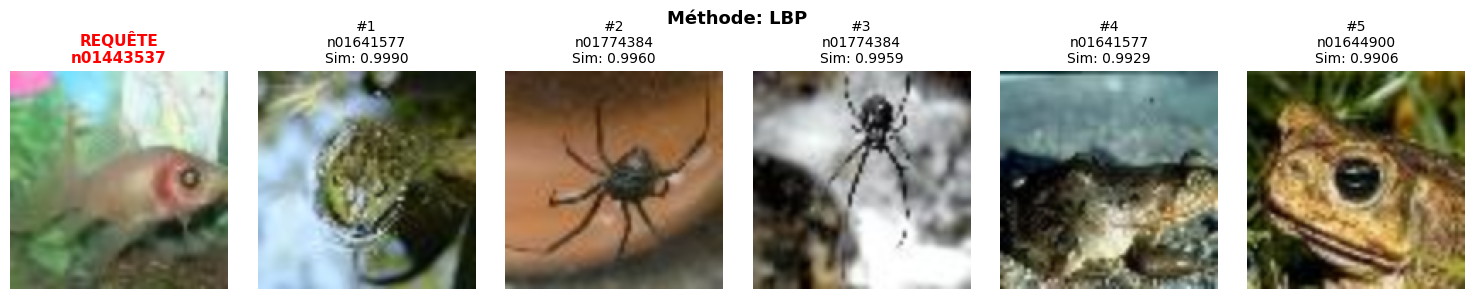


Méthode: HOG


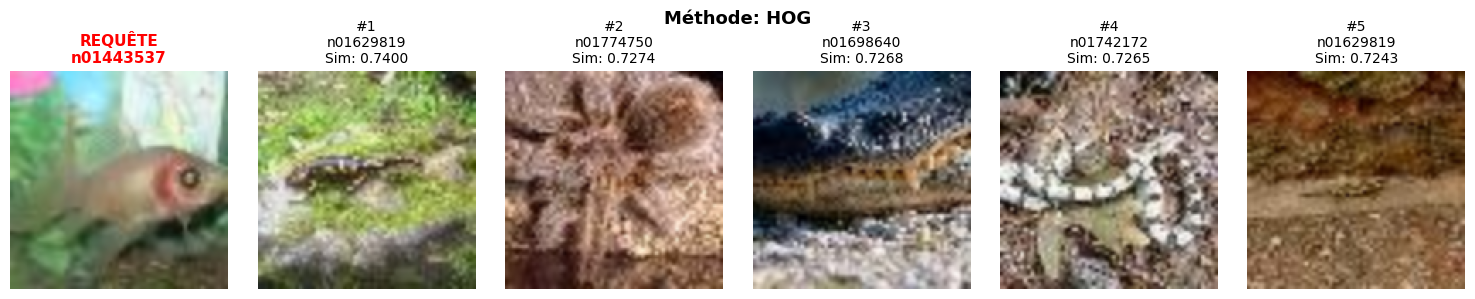


Méthode: CNN


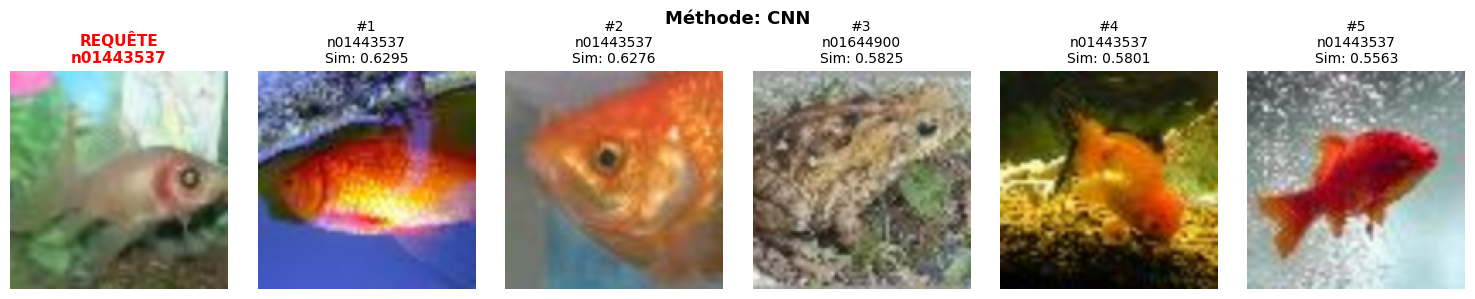

In [ ]:
import matplotlib.pyplot as plt
import cv2

def display_search_results(query_idx, method_name, k=5):
    indices, sims = search_similar_images(query_idx, method_name, k)

    fig, axes = plt.subplots(1, k+1, figsize=(15, 3))

    # Image requête
    axes[0].imshow(cv2.cvtColor(images[query_idx], cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"REQUÊTE\n{class_names[labels[query_idx]]}",
                      color='red', fontweight='bold', fontsize=11)
    axes[0].axis('off')

    # Images similaires
    for i, (idx, sim) in enumerate(zip(indices, sims), 1):
        axes[i].imshow(cv2.cvtColor(images[idx], cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"#{i}\n{class_names[labels[idx]]}\nSim: {sim:.4f}", fontsize=10)
        axes[i].axis('off')

    plt.suptitle(f"Méthode: {method_name}", fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()

# Afficher pour toutes les méthodes
query_idx = 0
k = 5

for method in ["SIFT", "LBP", "HOG", "CNN"]:
    print(f"\n{'='*50}\nMéthode: {method}\n{'='*50}")
    display_search_results(query_idx, method, k)